# Mineração de Dados – Saúde Mental de Adolescentes
**Dataset:** Cirrhosis Patient Survival Prediction (Uc Irvine)  
**Disciplina:** Mineração de Dados | Campus Birigui – IFSP  

---
## 1. Seleção e Pré-processamento de Dados


In [35]:
# Instalação e importações
import subprocess, sys

for pkg in ['pandas','numpy','scikit-learn','seaborn','matplotlib','scipy','imbalanced-learn']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
# Leitura do dataset
cirrose_df = pd.read_csv("cirrhosis.csv")
cirrose_df.columns = cirrose_df.columns.str.strip()

print("=== Características da Base de Dados ===")
print(f"Amostras  : {cirrose_df.shape[0]}")
print(f"Atributos : {cirrose_df.shape[1]}")
print()
cirrose_df.info()
print(cirrose_df.columns)

=== Características da Base de Dados ===
Amostras  : 418
Atributos : 20

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    str    
 3   Drug           312 non-null    str    
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    str    
 6   Ascites        312 non-null    str    
 7   Hepatomegaly   312 non-null    str    
 8   Spiders        312 non-null    str    
 9   Edema          418 non-null    str    
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float

In [37]:
print("=== Valores Ausentes por Coluna ===")
print(cirrose_df.isnull().sum())

print("\n=== Registros Duplicados ===")
print(cirrose_df.duplicated().sum())

print("\n=== Variáveis Categóricas ===")
for col in cirrose_df.select_dtypes(include='object'):
    print(f"\n{col}")
    print(cirrose_df[col].value_counts())

=== Valores Ausentes por Coluna ===
ID                 0
N_Days             0
Status             0
Drug             106
Age                0
Sex                0
Ascites          106
Hepatomegaly     106
Spiders          106
Edema              0
Bilirubin          0
Cholesterol      134
Albumin            0
Copper           108
Alk_Phos         106
SGOT             106
Tryglicerides    136
Platelets         11
Prothrombin        2
Stage              6
dtype: int64

=== Registros Duplicados ===
0

=== Variáveis Categóricas ===

Status
Status
C     232
D     161
CL     25
Name: count, dtype: int64

Drug
Drug
D-penicillamine    158
Placebo            154
Name: count, dtype: int64

Sex
Sex
F    374
M     44
Name: count, dtype: int64

Ascites
Ascites
N    288
Y     24
Name: count, dtype: int64

Hepatomegaly
Hepatomegaly
Y    160
N    152
Name: count, dtype: int64

Spiders
Spiders
N    222
Y     90
Name: count, dtype: int64

Edema
Edema
N    354
S     44
Y     20
Name: count, dtype: int64


C:\Users\hugop\AppData\Local\Temp\ipykernel_19232\710363859.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in cirrose_df.select_dtypes(include='object'):


In [38]:
# Verificação inicial
print("=== Antes da Limpeza ===")
print(f"Amostras: {cirrose_df.shape[0]}")
print(f"Valores nulos: {cirrose_df.isnull().sum().sum()}")
print(f"Duplicados: {cirrose_df.duplicated().sum()}")

# Remover duplicados
cirrose_df = cirrose_df.drop_duplicates()

# Remover espaços extras em colunas categóricas
for col in cirrose_df.select_dtypes(include='object'):
    cirrose_df[col] = cirrose_df[col].str.strip()

# Preenchimento de variáveis numéricas com a mediana
num_cols = cirrose_df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    cirrose_df[col] = cirrose_df[col].fillna(cirrose_df[col].median())

# Preenchimento de variáveis categóricas com a moda
cat_cols = cirrose_df.select_dtypes(include='object').columns

for col in cat_cols:
    cirrose_df[col] = cirrose_df[col].fillna(cirrose_df[col].mode()[0])

# Verificação final
print("\n=== Após Limpeza ===")
print(f"Amostras: {cirrose_df.shape[0]}")
print(f"Duplicados restantes: {cirrose_df.duplicated().sum()}")
print(f"Valores nulos restantes: {cirrose_df.isnull().sum().sum()}")

=== Antes da Limpeza ===
Amostras: 418
Valores nulos: 1033
Duplicados: 0

=== Após Limpeza ===
Amostras: 418
Duplicados restantes: 0
Valores nulos restantes: 0


C:\Users\hugop\AppData\Local\Temp\ipykernel_19232\1245763080.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in cirrose_df.select_dtypes(include='object'):
C:\Users\hugop\AppData\Local\Temp\ipykernel_19232\1245763080.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guid

=== Distribuição das Classes ===
Stage
3.0    161
4.0    144
2.0     92
1.0     21
Name: count, dtype: int64

Stage
3.0    38.52%
4.0    34.45%
2.0    22.01%
1.0     5.02%
Name: proportion, dtype: str


C:\Users\hugop\AppData\Local\Temp\ipykernel_19232\3087723143.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Stage', data=cirrose_df, palette='Set2')


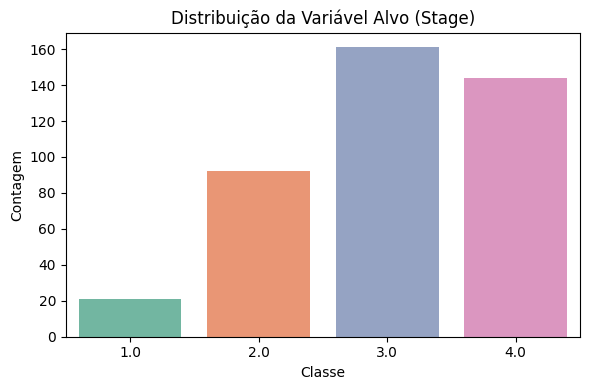

In [39]:
# Verificação de desbalanceamento de classes
print("=== Distribuição das Classes ===")
print(cirrose_df['Stage'].value_counts())
print()
print(cirrose_df['Stage'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

plt.figure(figsize=(6,4))
sns.countplot(x='Stage', data=cirrose_df, palette='Set2')
plt.title('Distribuição da Variável Alvo (Stage)')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.tight_layout()
plt.show()

---
## 2. Normalização e Redução de Dados

In [40]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

X = cirrose_df.drop(columns=['Stage', 'ID'])
y = cirrose_df['Stage']

cat_cols = X.select_dtypes(include = 'object').columns.tolist()
print(f"Colunas categóricas codificadas: {cat_cols}")

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)     

#normalização Min-Max
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled = pd.DataFrame(X_scaled, columns=X_encoded.columns)

print("\nNormalização aplicada: Min-Max Scaler")
print(f"Shape após codificação e normalização: {X_scaled.shape}")
X_scaled.head()

Colunas categóricas codificadas: ['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']

Normalização aplicada: Min-Max Scaler
Shape após codificação e normalização: (418, 20)


C:\Users\hugop\AppData\Local\Temp\ipykernel_19232\3122039751.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include = 'object').columns.tolist()


,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Status_CL,Status_D,Drug_Placebo,Sex_M,Ascites_Y,Hepatomegaly_Y,Spiders_Y,Edema_S,Edema_Y
0,0.075515,0.622822,0.512635,0.085196,0.238806,0.260274,0.105279,0.258993,0.246018,0.194234,0.355556,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
1,0.937947,0.578364,0.028881,0.109970,0.813433,0.085616,0.523509,0.202298,0.097345,0.241275,0.177778,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,0.204249,0.839597,0.039711,0.033837,0.567164,0.352740,0.016724,0.161871,0.038938,0.135053,0.333333,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.396298,0.545664,0.054152,0.074924,0.216418,0.102740,0.429723,0.079554,0.104425,0.183612,0.144444,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4,0.307741,0.226748,0.111913,0.096073,0.585821,0.238014,0.028143,0.201439,0.069027,0.112291,0.211111,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


Variância explicada por cada componente:
  PC1: 23.90%
  PC2: 17.55%
Variância total explicada: 41.45%


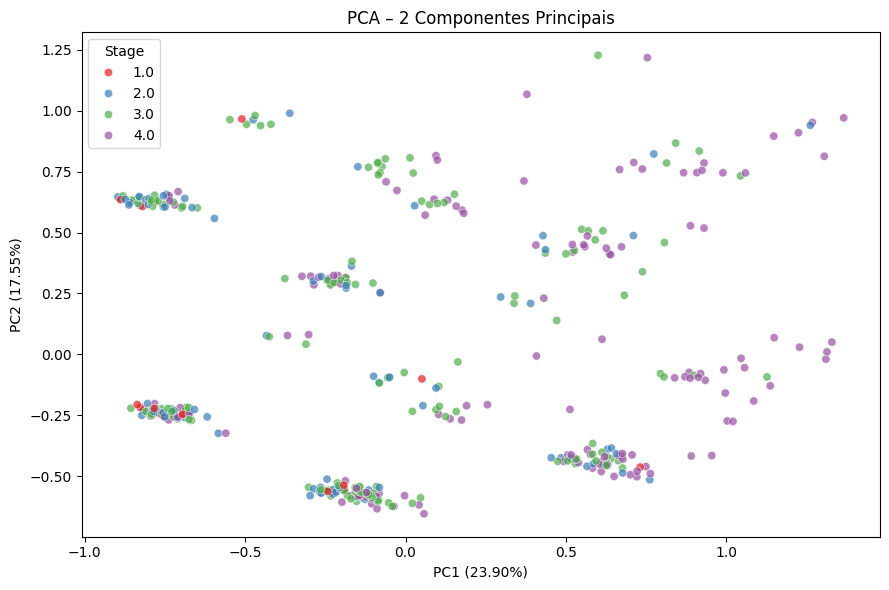

=== Loadings do PCA ===
                  PC1    PC2
Status_D        0.676  0.136
Hepatomegaly_Y  0.528 -0.322
Spiders_Y       0.306  0.318
Ascites_Y       0.154  0.062
Bilirubin       0.141  0.047
Edema_Y         0.131  0.081
Edema_S         0.122 -0.043
Copper          0.088  0.038
Age             0.085 -0.071
Prothrombin     0.075  0.026
SGOT            0.052  0.028
Sex_M           0.044 -0.033
Alk_Phos        0.036  0.030
Tryglicerides   0.035  0.019
Cholesterol     0.028  0.024
Drug_Placebo   -0.045  0.866
Status_CL      -0.047 -0.025
Platelets      -0.058  0.021
Albumin        -0.115  0.009
N_Days         -0.212  0.012


<Figure size 1000x600 with 0 Axes>

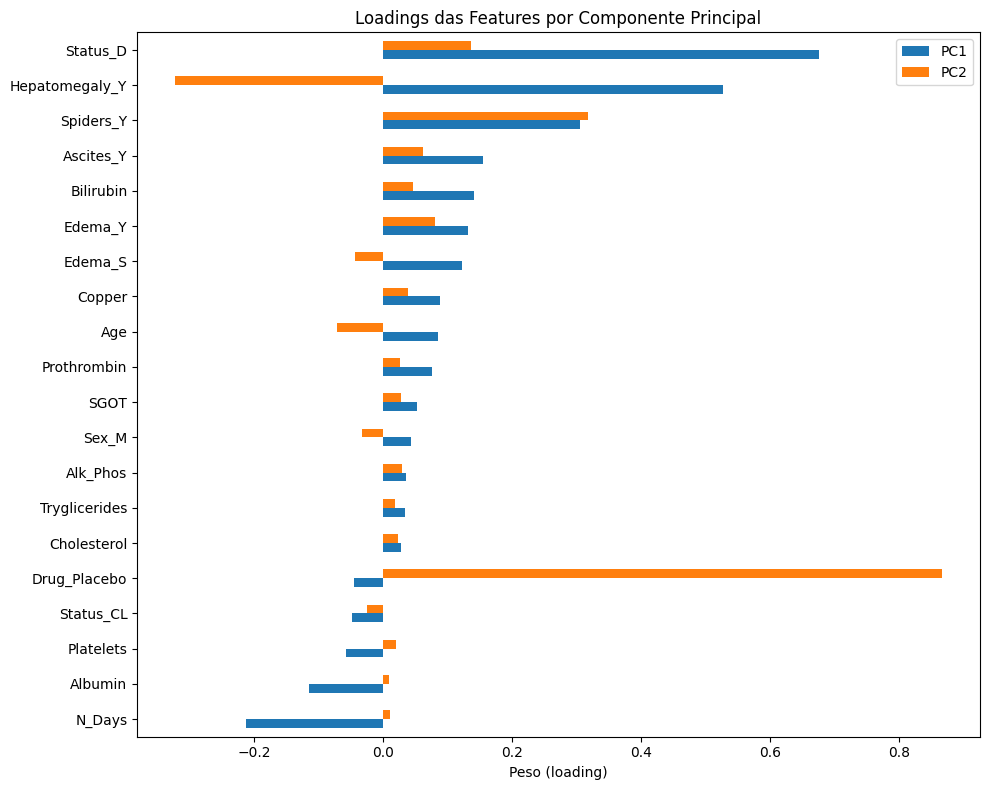

In [41]:
# PCA – 2 principais componentes
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
pca_df['Stage'] = y.values

print("Variância explicada por cada componente:")
for i, v in enumerate(pca_2d.explained_variance_ratio_, 1):
    print(f"  PC{i}: {v*100:.2f}%")
print(f"Variância total explicada: {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")

plt.figure(figsize=(9,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Stage', palette='Set1', alpha=0.7)
plt.title('PCA – 2 Componentes Principais')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)')
plt.legend(title='Stage')
plt.tight_layout()
plt.show()

# Loadings do PCA
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=X_scaled.columns,
    columns=['PC1', 'PC2']
)

print("=== Loadings do PCA ===")
print(loadings.sort_values('PC1', ascending=False).round(3))

# Visualização
plt.figure(figsize=(10, 6))
loadings.sort_values('PC1').plot(kind='barh', figsize=(10, 8))
plt.title('Loadings das Features por Componente Principal')
plt.xlabel('Peso (loading)')
plt.tight_layout()
plt.show()

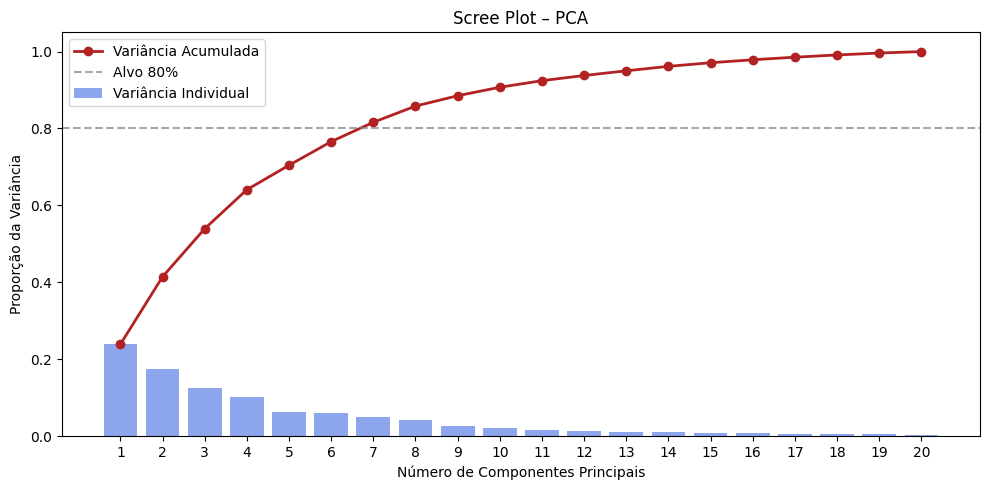

In [42]:
# Scree Plot – análise da variância acumulada
pca_all = PCA()
pca_all.fit(X_scaled)
exp_var = pca_all.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(exp_var)+1), exp_var, alpha=0.6, color='royalblue', label='Variância Individual')
plt.plot(range(1, len(exp_var)+1), cum_var, marker='o', color='firebrick', linewidth=2, label='Variância Acumulada')
plt.axhline(y=0.80, color='gray', linestyle='--', alpha=0.7, label='Alvo 80%')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Proporção da Variância')
plt.title('Scree Plot – PCA')
plt.xticks(range(1, len(exp_var)+1))
plt.legend()
plt.tight_layout()
plt.show()

---
## 3. Análise Descritiva – Visualização

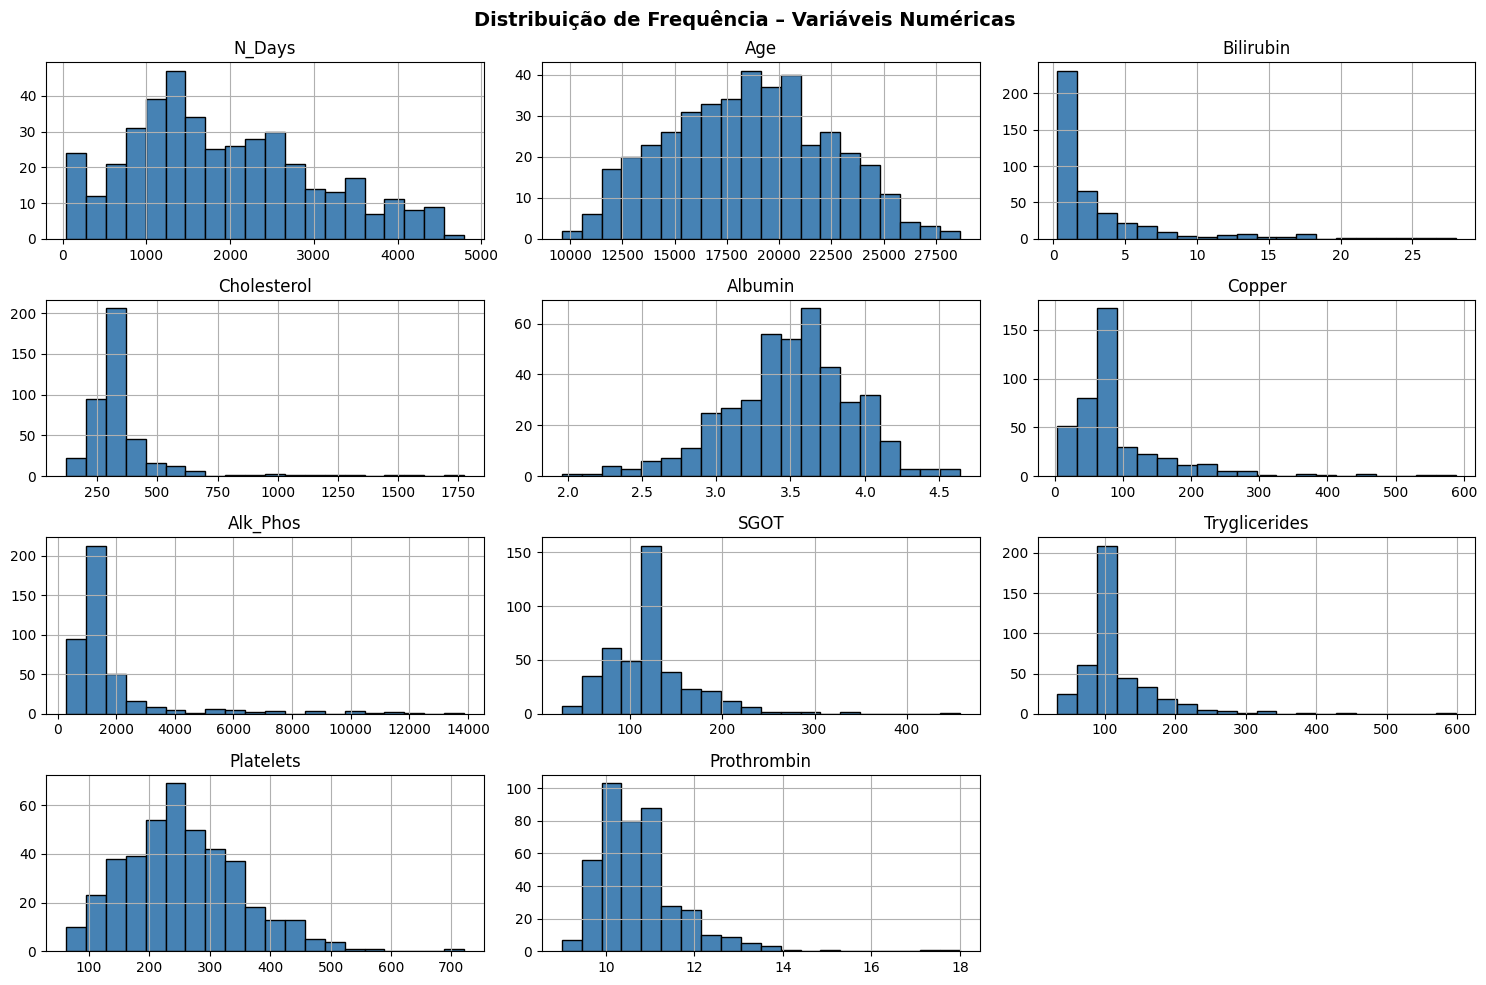

In [43]:
# Distribuição de frequência das variáveis numéricas
num_cols = [
    'N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin',
    'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin'
]

cirrose_df[num_cols].hist(figsize=(15, 10), bins=20, edgecolor='black', color='steelblue')
plt.suptitle('Distribuição de Frequência – Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

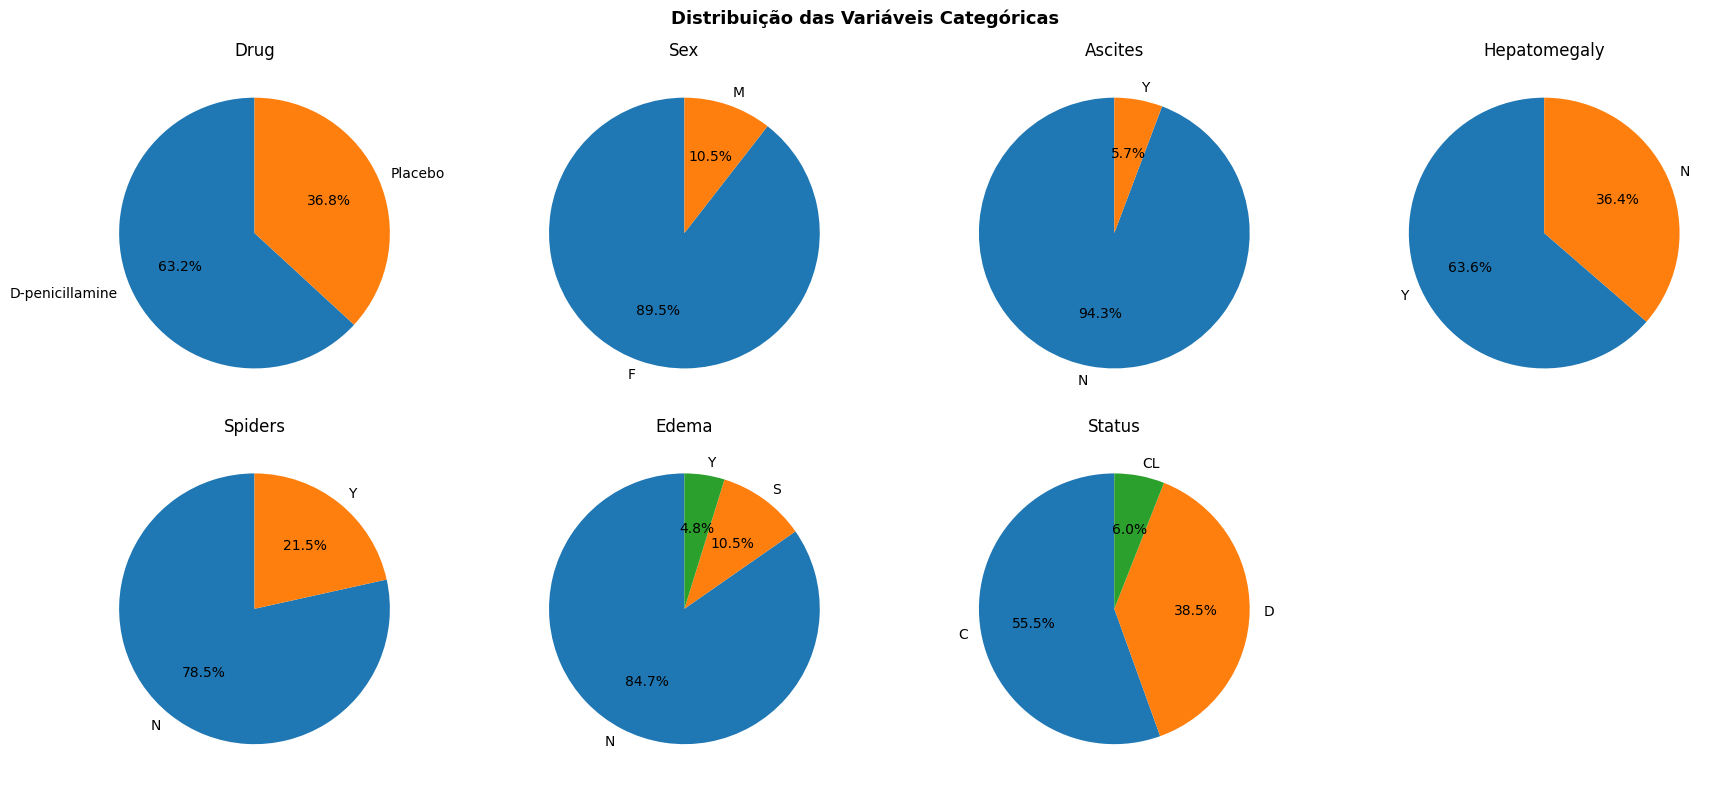

In [44]:
# Gráficos de setores – variáveis categóricas
cat_cols = ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Status']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    counts = cirrose_df[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
    ax.set_title(col)

# Esconder o subplot vazio (7 colunas, 8 espaços)
axes[-1].set_visible(False)

plt.suptitle('Distribuição das Variáveis Categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\hugop\AppData\Local\Temp\ipykernel_19232\3188510725.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Stage', y=col, data=cirrose_df, palette='Set2', ax=ax)
C:\Users\hugop\AppData\Local\Temp\ipykernel_19232\3188510725.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Stage', y=col, data=cirrose_df, palette='Set2', ax=ax)
C:\Users\hugop\AppData\Local\Temp\ipykernel_19232\3188510725.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Stage', y=col, data=cirrose_df, palette='Set2', ax=ax)
C:\Users\hugop\AppData\Local\Temp\

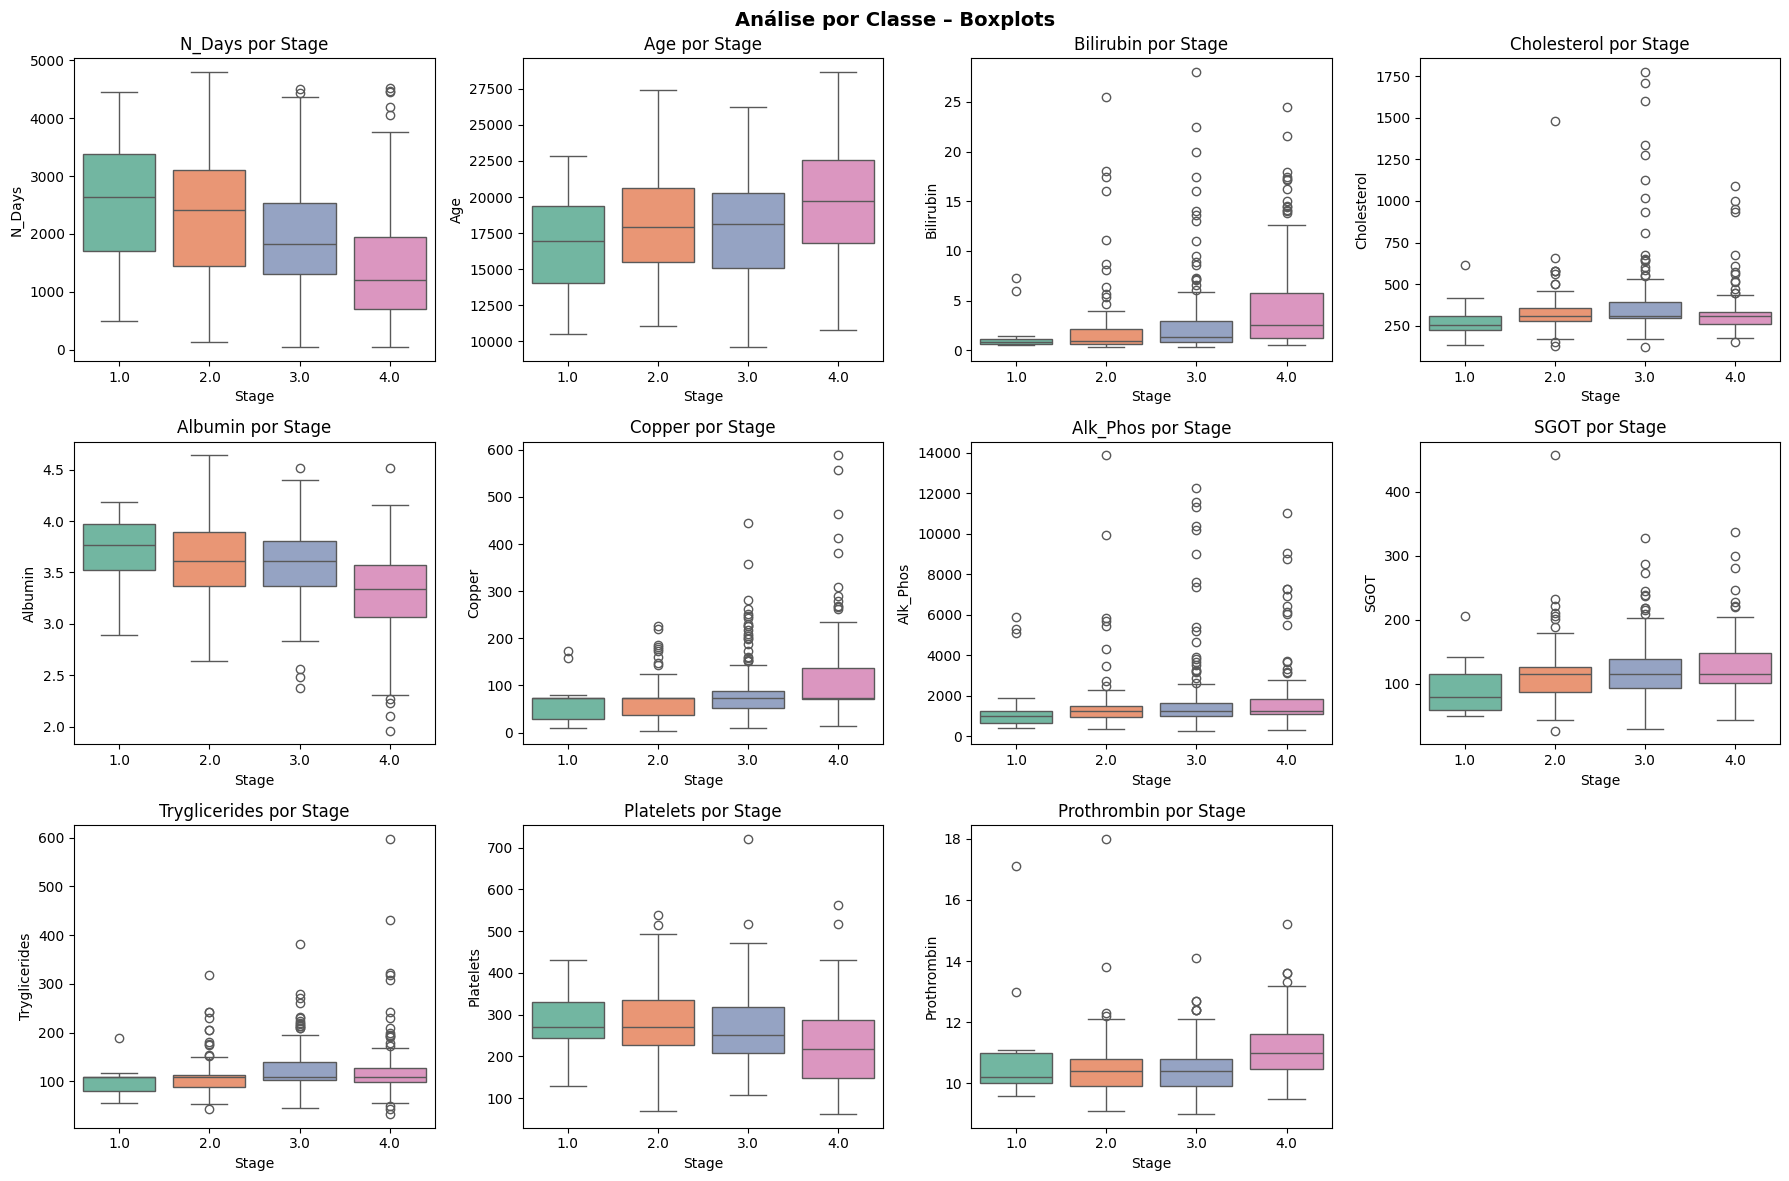

In [45]:
# Boxplots por classe (Stage)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
num_cols = ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin',
            'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']

for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(x='Stage', y=col, data=cirrose_df, palette='Set2', ax=ax)
    ax.set_title(f'{col} por Stage')
    ax.set_xlabel('Stage')

# Esconder subplots vazios (11 colunas, 12 espaços)
for ax in axes.flat[len(num_cols):]:
    ax.set_visible(False)

plt.suptitle('Análise por Classe – Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Análise Descritiva – Medidas Estatísticas

In [46]:
from scipy import stats

colunas_numericas = [
    'N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin',
    'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin'
]

def medidas_tendencia_central(df, col):
    s = df[col]
    return {'Media': s.mean(), 'Mediana': s.median(),
            'Ponto Medio': (s.max()+s.min())/2, 'Moda': s.mode()[0]}

def medidas_dispersao(df, col):
    s = df[col]; m = s.mean()
    return {'Amplitude': s.max()-s.min(), 'Variancia': s.var(ddof=0),
            'Desvio Padrao': s.std(ddof=0),
            'Coef. Variacao (%)': (s.std(ddof=0)/m)*100 if m != 0 else None}

def medidas_posicao_relativa(df, col):
    s = df[col]; z = stats.zscore(s)
    return {'Menor Z-score': z.min(), 'Maior Z-score': z.max(),
            'Q1': s.quantile(0.25), 'Q2 (Mediana)': s.quantile(0.50),
            'Q3': s.quantile(0.75), 'IQR': s.quantile(0.75)-s.quantile(0.25)}

resultados = []
for col in colunas_numericas:
    r = {'Coluna': col}
    r.update(medidas_tendencia_central(cirrose_df, col))
    r.update(medidas_dispersao(cirrose_df, col))
    r.update(medidas_posicao_relativa(cirrose_df, col))
    resultados.append(r)

df_resumo = pd.DataFrame(resultados).round(4)
df_resumo

,Coluna,Media,Mediana,Ponto Medio,Moda,Amplitude,Variancia,Desvio Padrao,Coef. Variacao (%),Menor Z-score,Maior Z-score,Q1,Q2 (Mediana),Q3,IQR
0,N_Days,1917.7823,1730.00,2418.00,41.00,4754.00,1.217383e+06,1103.3508,57.5326,-1.7010,2.6077,1092.7500,1730.00,2613.50,1520.7500
1,Age,18533.3517,18628.00,19124.00,19724.00,19052.00,1.452584e+07,3811.2779,20.5644,-2.3445,2.6544,15644.5000,18628.00,21272.50,5628.0000
2,Bilirubin,3.2208,1.40,14.15,0.70,27.70,1.937960e+01,4.4022,136.6807,-0.6635,5.6288,0.8000,1.40,3.40,2.6000
3,Cholesterol,350.2727,309.50,947.50,309.50,1655.00,3.720761e+04,192.8927,55.0693,-1.1938,7.3861,273.0000,309.50,347.75,74.7500
4,Albumin,3.4974,3.53,3.30,3.35,2.68,1.802000e-01,0.4245,12.1364,-3.6221,2.6918,3.2425,3.53,3.77,0.5275
5,Copper,91.2799,73.00,296.00,73.00,584.00,5.534814e+03,74.3963,81.5035,-1.1732,6.6767,51.2500,73.00,100.75,49.5000
6,Alk_Phos,1799.1450,1259.00,7075.70,1259.00,13573.40,3.507671e+06,1872.8777,104.0982,-0.8063,6.4410,1016.2500,1259.00,1707.75,691.5000
7,SGOT,120.5641,114.70,241.80,114.70,430.90,2.403582e+03,49.0263,40.6641,-1.9217,6.8674,91.0000,114.70,135.75,44.7500
8,Tryglicerides,119.2679,108.00,315.50,108.00,565.00,2.914488e+03,53.9860,45.2645,-1.5980,8.8677,95.0000,108.00,127.75,32.7500
9,Platelets,256.8660,251.00,391.50,251.00,659.00,9.391303e+03,96.9087,37.7273,-2.0108,4.7894,190.0000,251.00,315.50,125.5000


=== Medidas de Associação ===

Bilirubin  ×  Copper
  Covariância : 132.2358
  Correlação  : 0.4038

Albumin  ×  Prothrombin
  Covariância : -0.0858
  Correlação  : -0.1984

Alk_Phos  ×  SGOT
  Covariância : 11208.5677
  Correlação  : 0.1221

Cholesterol  ×  Tryglicerides
  Covariância : 3038.1375
  Correlação  : 0.2917


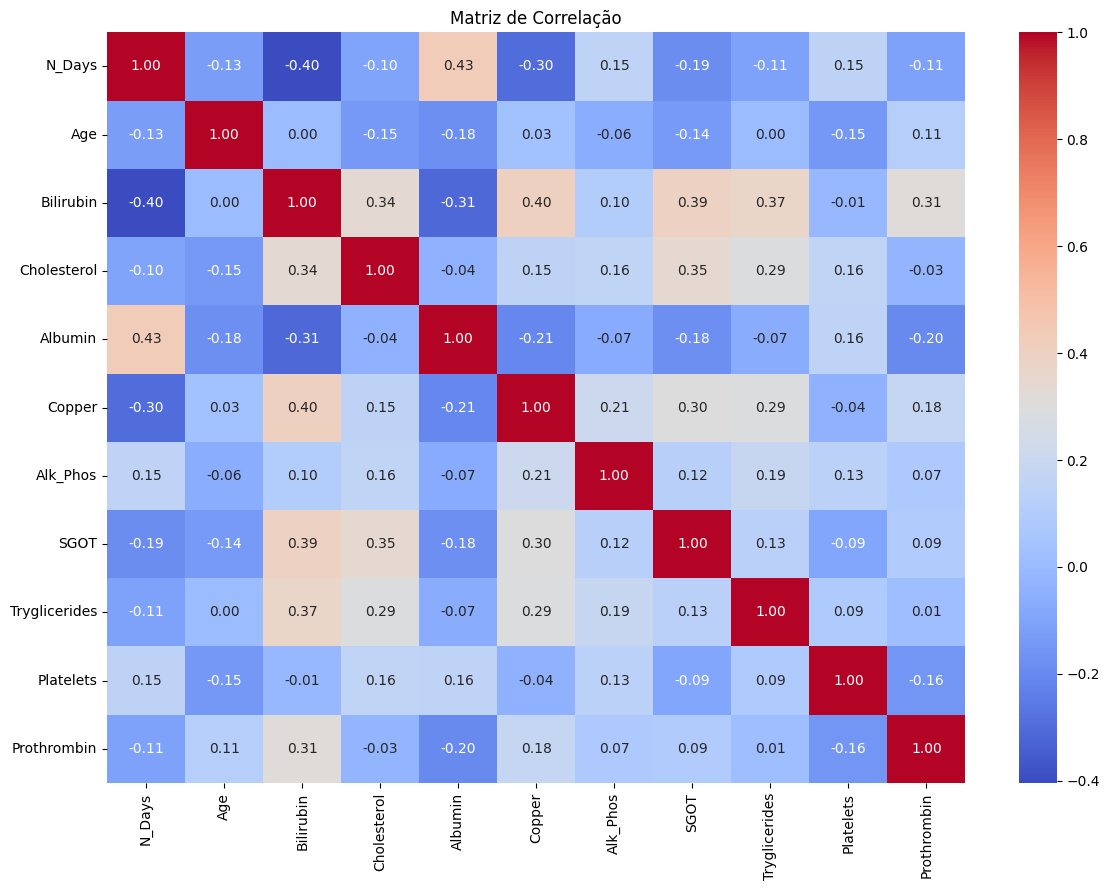

In [47]:
from scipy import stats

# Medidas de associação (Covariância e Correlação de Pearson)
pares = [
    ('Bilirubin', 'Copper'),
    ('Albumin', 'Prothrombin'),
    ('Alk_Phos', 'SGOT'),
    ('Cholesterol', 'Tryglicerides')
]

print("=== Medidas de Associação ===")
for c1, c2 in pares:
    cov = np.cov(cirrose_df[c1], cirrose_df[c2], ddof=0)[0,1]
    cor = cirrose_df[c1].corr(cirrose_df[c2])
    print(f"\n{c1}  ×  {c2}")
    print(f"  Covariância : {cov:.4f}")
    print(f"  Correlação  : {cor:.4f}")

# Matriz de correlação
plt.figure(figsize=(12, 9))
corr_matrix = cirrose_df[['N_Days','Age','Bilirubin','Cholesterol','Albumin',
                           'Copper','Alk_Phos','SGOT','Tryglicerides',
                           'Platelets','Prothrombin']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

---
## 5. Análise de Grupos (Clustering)

In [48]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, homogeneity_score
from sklearn.metrics.pairwise import manhattan_distances

# Redução para 2 componentes (features numéricas somente)
num_cols_cluster = [
    'N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin',
    'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin'
]

X_num_scaled = MinMaxScaler().fit_transform(cirrose_df[num_cols_cluster])
pca_clust = PCA(n_components=2)
X_pca_clust = pca_clust.fit_transform(X_num_scaled)
print(f"Variância explicada (PCA 2D para clustering): {sum(pca_clust.explained_variance_ratio_)*100:.2f}%")

Variância explicada (PCA 2D para clustering): 47.58%


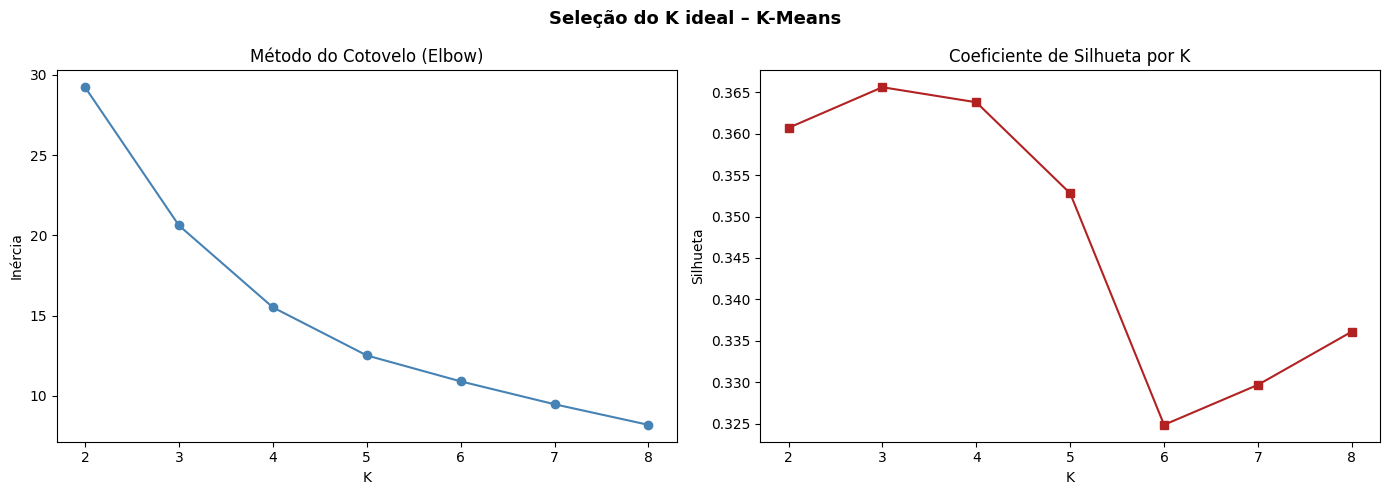

In [49]:
# K-Means: variando K de 2 a 8 com gráfico Elbow + Silhueta
inertias, silhuetas = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_pca_clust)
    inertias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_pca_clust, lbl))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, marker='o', color='steelblue')
axes[0].set_title('Método do Cotovelo (Elbow)')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inércia')
axes[1].plot(list(K_range), silhuetas, marker='s', color='firebrick')
axes[1].set_title('Coeficiente de Silhueta por K')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhueta')
plt.suptitle('Seleção do K ideal – K-Means', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

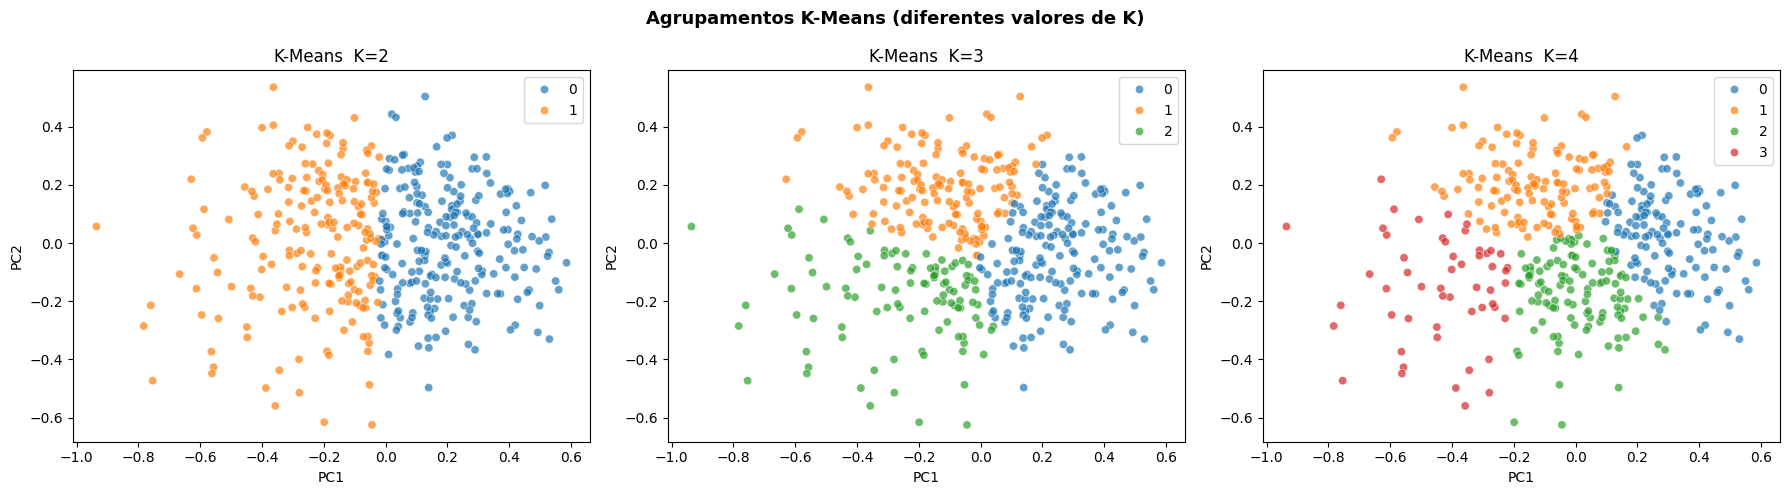

In [50]:
# Plotar agrupamentos K-Means para K = 2, 3, 4
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, k in zip(axes, [2, 3, 4]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_pca_clust)
    sns.scatterplot(x=X_pca_clust[:,0], y=X_pca_clust[:,1], hue=lbl,
                    palette='tab10', alpha=0.7, ax=ax, legend='full')
    ax.set_title(f'K-Means  K={k}'); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.suptitle('Agrupamentos K-Means (diferentes valores de K)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

--- Distância Euclidiana ---
  Silhueta     : 0.3656
  Homogeneidade: 0.0527

--- Distância Manhattan ---
  Silhueta     : 0.3162
  Homogeneidade: 0.0677


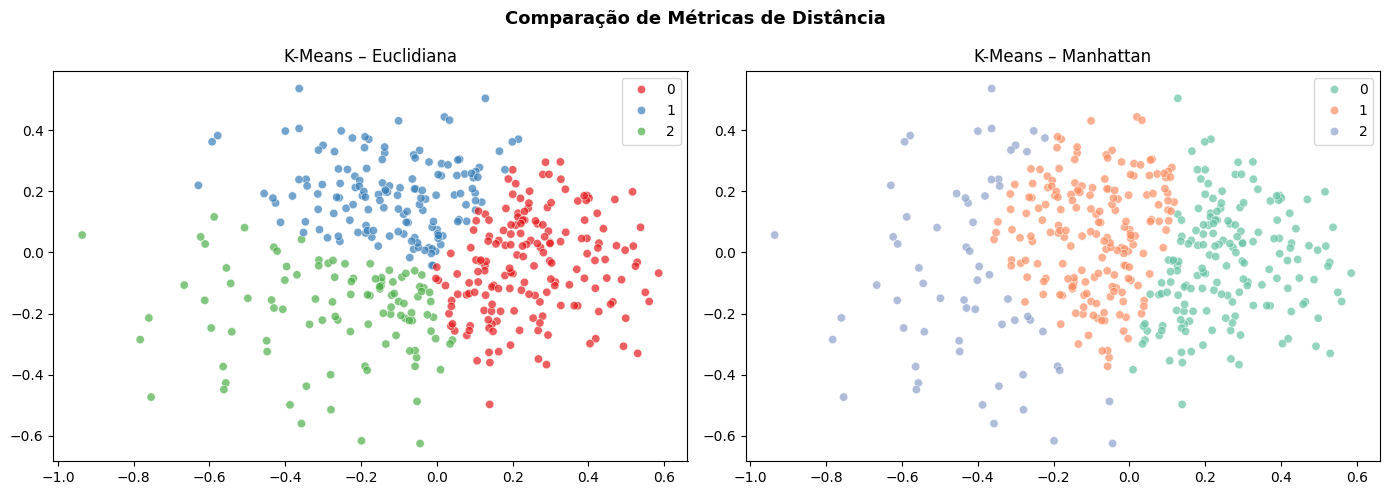

In [51]:
# K-Means com diferentes métricas de distância: Euclidiana vs Manhattan
kmeans_euc = KMeans(n_clusters=3, random_state=42, n_init=10)
lbl_euc = kmeans_euc.fit_predict(X_pca_clust)

X_manhattan = manhattan_distances(X_pca_clust)
kmeans_man = KMeans(n_clusters=3, random_state=42, n_init=10)
lbl_man = kmeans_man.fit_predict(X_manhattan)

print("--- Distância Euclidiana ---")
print(f"  Silhueta     : {silhouette_score(X_pca_clust, lbl_euc):.4f}")
print(f"  Homogeneidade: {homogeneity_score(cirrose_df['Stage'], lbl_euc):.4f}")

print("\n--- Distância Manhattan ---")
print(f"  Silhueta     : {silhouette_score(X_manhattan, lbl_man, metric='precomputed'):.4f}")
print(f"  Homogeneidade: {homogeneity_score(cirrose_df['Stage'], lbl_man):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=X_pca_clust[:,0], y=X_pca_clust[:,1], hue=lbl_euc, palette='Set1', ax=axes[0], alpha=0.7)
axes[0].set_title('K-Means – Euclidiana')
sns.scatterplot(x=X_pca_clust[:,0], y=X_pca_clust[:,1], hue=lbl_man, palette='Set2', ax=axes[1], alpha=0.7)
axes[1].set_title('K-Means – Manhattan')
plt.suptitle('Comparação de Métricas de Distância', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

--- Silhueta por K (GMM) ---
  K=2: 0.3556
  K=3: 0.3598
  K=4: 0.3569
  K=5: 0.3407

--- GMM K=4 ---
  Silhueta     : 0.3569
  Homogeneidade: 0.0655


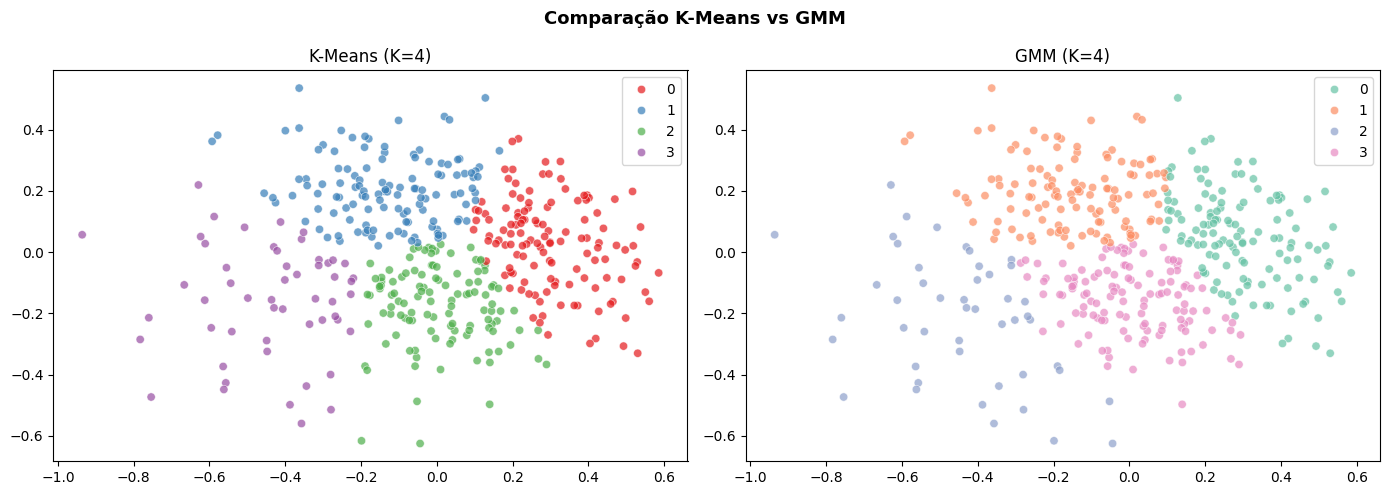

In [52]:
# GMM – testando K e comparando com K-Means
print("--- Silhueta por K (GMM) ---")
for k in range(2, 6):
    gmm = GaussianMixture(n_components=k, random_state=42)
    lbl = gmm.fit_predict(X_pca_clust)
    print(f"  K={k}: {silhouette_score(X_pca_clust, lbl):.4f}")

gmm_final = GaussianMixture(n_components=4, random_state=42)
lbl_gmm = gmm_final.fit_predict(X_pca_clust)

# K-Means K=4 para comparação
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
lbl_km4 = km4.fit_predict(X_pca_clust)

print(f"\n--- GMM K=4 ---")
print(f"  Silhueta     : {silhouette_score(X_pca_clust, lbl_gmm):.4f}")
print(f"  Homogeneidade: {homogeneity_score(cirrose_df['Stage'], lbl_gmm):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=X_pca_clust[:,0], y=X_pca_clust[:,1], hue=lbl_km4, palette='Set1', ax=axes[0], alpha=0.7)
axes[0].set_title('K-Means (K=4)')
sns.scatterplot(x=X_pca_clust[:,0], y=X_pca_clust[:,1], hue=lbl_gmm, palette='Set2', ax=axes[1], alpha=0.7)
axes[1].set_title('GMM (K=4)')
plt.suptitle('Comparação K-Means vs GMM', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 6. Classificação    

In [53]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold, StratifiedKFold, train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print("imbalanced-learn não disponível – pulando SMOTE")

# ── Preparação de dados ──────────────────────────────────────────────────────
x_cls = cirrose_df.drop(columns=['Stage', 'ID'])
y_cls = cirrose_df['Stage']

cat_cols_cls = x_cls.select_dtypes(include='object').columns.tolist()
X_enc = pd.get_dummies(x_cls, columns=cat_cols_cls, drop_first=True)

# Holdout 70/30 estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y_cls, test_size=0.3, random_state=42, stratify=y_cls
)

scaler_cls = MinMaxScaler()
X_train_s = scaler_cls.fit_transform(X_train)
X_test_s  = scaler_cls.transform(X_test)

# SMOTE no treino (se disponível)
if SMOTE_AVAILABLE:
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_train_s, y_train)
    print("SMOTE aplicado – distribuição após balanceamento:")
    print(pd.Series(y_res).value_counts())
else:
    X_res, y_res = X_train_s, y_train

cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
print(f"\nHoldout – treino: {X_train_s.shape[0]}  teste: {X_test_s.shape[0]}")

SMOTE aplicado – distribuição após balanceamento:
Stage
3.0    112
4.0    112
2.0    112
1.0    112
Name: count, dtype: int64

Holdout – treino: 292  teste: 126


C:\Users\hugop\AppData\Local\Temp\ipykernel_19232\1520259685.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_cls = x_cls.select_dtypes(include='object').columns.tolist()


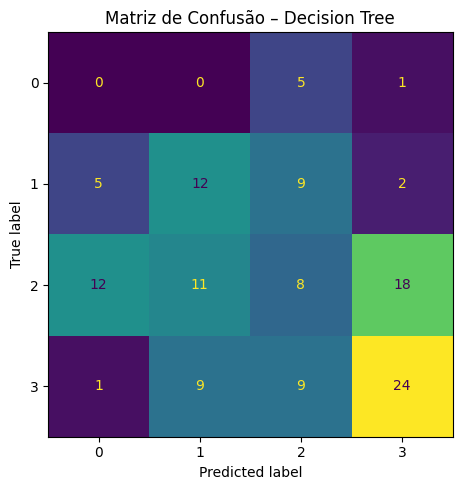


=== Decision Tree ===
  Holdout  – Acurácia: 0.3492  |  F1 Macro: 0.2864
  CV k=10  – Acurácia: 0.4113  |  F1 Macro: 0.3279
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         6
         2.0       0.38      0.43      0.40        28
         3.0       0.26      0.16      0.20        49
         4.0       0.53      0.56      0.55        43

    accuracy                           0.35       126
   macro avg       0.29      0.29      0.29       126
weighted avg       0.37      0.35      0.35       126



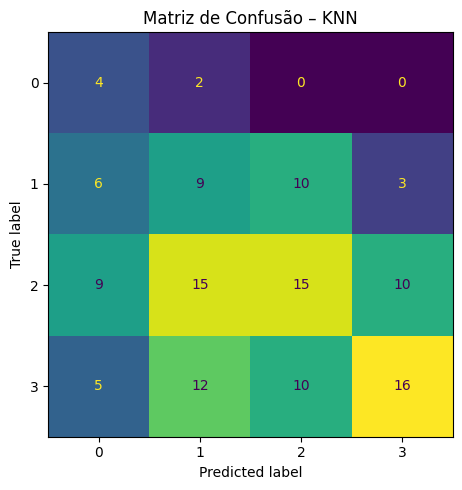


=== KNN ===
  Holdout  – Acurácia: 0.3492  |  F1 Macro: 0.3352
  CV k=10  – Acurácia: 0.4613  |  F1 Macro: 0.3303
              precision    recall  f1-score   support

         1.0       0.17      0.67      0.27         6
         2.0       0.24      0.32      0.27        28
         3.0       0.43      0.31      0.36        49
         4.0       0.55      0.37      0.44        43

    accuracy                           0.35       126
   macro avg       0.35      0.42      0.34       126
weighted avg       0.42      0.35      0.36       126



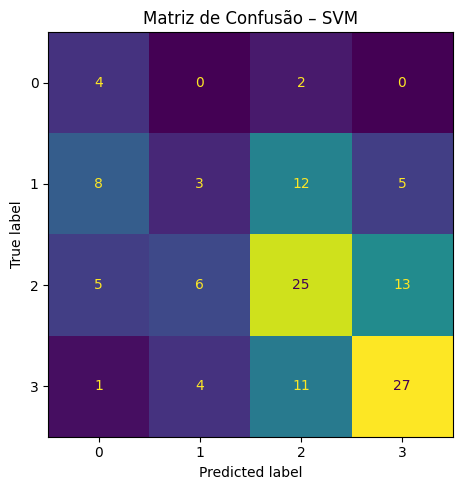


=== SVM ===
  Holdout  – Acurácia: 0.4683  |  F1 Macro: 0.3996
  CV k=10  – Acurácia: 0.4639  |  F1 Macro: 0.2769
              precision    recall  f1-score   support

         1.0       0.22      0.67      0.33         6
         2.0       0.23      0.11      0.15        28
         3.0       0.50      0.51      0.51        49
         4.0       0.60      0.63      0.61        43

    accuracy                           0.47       126
   macro avg       0.39      0.48      0.40       126
weighted avg       0.46      0.47      0.45       126



c:\Users\hugop\OneDrive\mentalHealth\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\hugop\OneDrive\mentalHealth\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\hugop\OneDrive\mentalHealth\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\hugop\OneDrive\mentalHealth\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


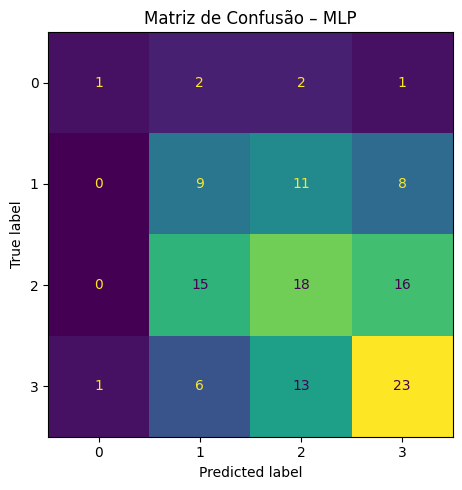


=== MLP ===
  Holdout  – Acurácia: 0.4048  |  F1 Macro: 0.3606
  CV k=10  – Acurácia: 0.4548  |  F1 Macro: 0.3523
              precision    recall  f1-score   support

         1.0       0.50      0.17      0.25         6
         2.0       0.28      0.32      0.30        28
         3.0       0.41      0.37      0.39        49
         4.0       0.48      0.53      0.51        43

    accuracy                           0.40       126
   macro avg       0.42      0.35      0.36       126
weighted avg       0.41      0.40      0.40       126


=== Comparação Final dos Classificadores ===
       Modelo  Acurácia Holdout  F1 Holdout  Acurácia CV  F1 CV
Decision Tree            0.3492      0.2864       0.4113 0.3279
          KNN            0.3492      0.3352       0.4613 0.3303
          SVM            0.4683      0.3996       0.4639 0.2769
          MLP            0.4048      0.3606       0.4548 0.3523


In [54]:
# ── Função auxiliar para avaliar um modelo ───────────────────────────────────
def avaliar_modelo(nome, modelo, X_train_s, X_test_s, y_train, y_test, X_res, y_res, cv10, X_enc, y_cls):
    
    # ── Holdout ──────────────────────────────────────────────────────────────
    modelo.fit(X_res, y_res)
    y_pred = modelo.predict(X_test_s)
    acc_holdout = accuracy_score(y_test, y_pred)
    f1_holdout  = f1_score(y_test, y_pred, average='macro', zero_division=0)

    # ── Cross-Validation ─────────────────────────────────────────────────────
    scaler_cv = MinMaxScaler()
    X_cv = scaler_cv.fit_transform(X_enc)
    acc_cv = cross_val_score(modelo, X_cv, y_cls, cv=cv10, scoring='accuracy').mean()
    f1_cv  = cross_val_score(modelo, X_cv, y_cls, cv=cv10, scoring='f1_macro').mean()

    # ── Matriz de Confusão ───────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=ax, colorbar=False)
    ax.set_title(f'Matriz de Confusão – {nome}')
    plt.tight_layout()
    plt.show()

    print(f"\n=== {nome} ===")
    print(f"  Holdout  – Acurácia: {acc_holdout:.4f}  |  F1 Macro: {f1_holdout:.4f}")
    print(f"  CV k=10  – Acurácia: {acc_cv:.4f}  |  F1 Macro: {f1_cv:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))

    return {'Modelo': nome,
            'Acurácia Holdout': acc_holdout, 'F1 Holdout': f1_holdout,
            'Acurácia CV':      acc_cv,       'F1 CV':      f1_cv}


# ── Definição dos modelos ────────────────────────────────────────────────────
modelos = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN':           KNeighborsClassifier(n_neighbors=5),
    'SVM':           SVC(kernel='rbf', random_state=42),
    'MLP':           MLPClassifier(hidden_layer_sizes=(100, 50),
                                   activation='relu',
                                   max_iter=500,
                                   random_state=42)
}

# ── Rodar todos os modelos ───────────────────────────────────────────────────
resultados = []
for nome, modelo in modelos.items():
    r = avaliar_modelo(nome, modelo, X_train_s, X_test_s,
                       y_train, y_test, X_res, y_res,
                       cv10, X_enc, y_cls)
    resultados.append(r)

# ── Tabela comparativa final ─────────────────────────────────────────────────
df_resultados = pd.DataFrame(resultados).round(4)
print("\n=== Comparação Final dos Classificadores ===")
print(df_resultados.to_string(index=False))